# CMS Overall Star Rating — OUTCOME_SAFETY Validation

**Purpose:** Explore and validate `OUTCOME_SAFETY.csv`, the Safety group-score output from the first-stage CMS Overall Star Rating pipeline.

This notebook is designed to be **self-contained first**. It checks the internal relationships that can be verified directly from `OUTCOME_SAFETY.csv`.

It also includes:

- **Check 11A:** a standalone validation that does not depend on another person's output.
- **Check 11B:** an optional direct comparison against the explicitly documented previous-step standardized output when that file is available.

This separation is intentional: the notebook remains useful even when the upstream reference file is not available yet.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# Find the project data directory from the repository root.
DATA = next(
    (
        p / "data/Project_1"
        for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "data/Project_1").exists()
    ),
    None
)

assert DATA is not None, (
    "Could not locate data/Project_1. "
    "Run this notebook from the repository or update DATA manually."
)

print("Data directory:", DATA)

Data directory: /Users/dianechege/Abt-Global-1B-ai-powered-sas-migration/data/Project_1


## 1. Load `OUTCOME_SAFETY.csv`

The Safety output contains standardized Safety measures (`std_...`), reporting flags (`C1`, `C2`, ...), and group-score fields such as `total_cnt`, `measure_wt`, `score_before_std`, `Mean`, `StdDev`, and `grp_score`.

The notebook identifies the standardized and flag columns from their naming patterns instead of assuming a particular number of Safety measures.

In [2]:
SAFETY_FILE = DATA / "SAS Output CSV/OUTCOME_SAFETY.csv"

assert SAFETY_FILE.exists(), (
    f"Could not find {SAFETY_FILE}. Check the DATA path and filename."
)

df = pd.read_csv(SAFETY_FILE)

print("Shape:", df.shape)
display(df.head())

Shape: (4566, 23)


,PROVIDER_ID,std_COMP_HIP_KNEE,std_HAI_1,std_HAI_2,std_HAI_3,std_HAI_4,std_HAI_5,std_HAI_6,std_PSI_90_SAFETY,C1,C2,C3,C4,C5,C6,C7,C8,total_cnt,measure_wt,score_before_std,Mean,StdDev,grp_score
0,010001,0.698729,0.303670,0.739078,-0.467783,NaN,0.476446,-0.105703,0.103001,1,1,1,1,0,1,1,1,7,0.142857,0.249634,-0.01903,0.779001,0.344883
1,010005,1.158692,-0.332255,-1.072825,1.149255,NaN,-2.749027,-0.428086,-0.058780,1,1,1,1,0,1,1,1,7,0.142857,-0.333289,-0.01903,0.779001,-0.403414
2,010006,-0.834482,0.977642,1.028777,1.149255,1.108414,0.595372,0.965067,-0.867684,1,1,1,1,1,1,1,1,8,0.125000,0.515295,-0.01903,0.779001,0.685911
3,010007,0.085445,NaN,NaN,NaN,NaN,NaN,-1.284702,0.372636,1,0,0,0,0,0,1,1,3,0.333333,-0.275540,-0.01903,0.779001,-0.329281
4,010008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,NaN,NaN,-0.01903,0.779001,NaN


## 2. Identify columns used for validation

We explicitly document the columns used by the checks.

- `std_...` columns = standardized Safety measures
- `C1`, `C2`, ... = reporting flags
- `PROVIDER_ID` = hospital identifier
- group-score columns = fields used to calculate the Safety group score

In [3]:
std_cols = [c for c in df.columns if c.startswith("std_")]
flag_cols = [c for c in df.columns if c.startswith("C") and c[1:].isdigit()]

required_cols = [
    "PROVIDER_ID", "total_cnt", "measure_wt",
    "score_before_std", "Mean", "StdDev", "grp_score"
]

missing_required = [c for c in required_cols if c not in df.columns]

print("Standardized measure columns:", std_cols)
print("Reporting flag columns:", flag_cols)
print("Missing required columns:", missing_required)

assert std_cols, "No std_ columns found."
assert flag_cols, "No C# flag columns found."
assert not missing_required, f"Missing required columns: {missing_required}"

print("Column-structure check: PASS")

Standardized measure columns: ['std_COMP_HIP_KNEE', 'std_HAI_1', 'std_HAI_2', 'std_HAI_3', 'std_HAI_4', 'std_HAI_5', 'std_HAI_6', 'std_PSI_90_SAFETY']
Reporting flag columns: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8']
Missing required columns: []
Column-structure check: PASS


## 3. Basic structure and provider ID checks

Before validating calculations, make sure the file represents one row per hospital.

A duplicated `PROVIDER_ID` would make hospital-level comparisons ambiguous.

In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing PROVIDER_ID:", df["PROVIDER_ID"].isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate PROVIDER_ID:", df["PROVIDER_ID"].duplicated().sum())
print("Unique providers:", df["PROVIDER_ID"].nunique())

assert df["PROVIDER_ID"].isna().sum() == 0
assert df["PROVIDER_ID"].duplicated().sum() == 0

print("Basic structure / ID check: PASS")

Rows: 4566
Columns: 23
Missing PROVIDER_ID: 0
Duplicate rows: 0
Duplicate PROVIDER_ID: 0
Unique providers: 4566
Basic structure / ID check: PASS


## 4. Missing-value analysis

Missing standardized measures are expected when a hospital does not have a reported value for a measure.

The goal here is to understand the pattern and then verify that the reporting flags and `total_cnt` agree with it. We do **not** impute or fill these missing values.

In [5]:
missing_summary = pd.DataFrame({
    "missing_count": df[std_cols].isna().sum(),
    "missing_pct": (df[std_cols].isna().mean() * 100).round(2),
    "reported_count": df[std_cols].notna().sum(),
}).sort_values("missing_count", ascending=False)

display(missing_summary)

print("Missing values in group-score fields:")
display(df[["total_cnt", "measure_wt", "score_before_std", "Mean", "StdDev", "grp_score"]].isna().sum())

,missing_count,missing_pct,reported_count
std_HAI_4,3919,85.83,647
std_HAI_5,2857,62.57,1709
std_COMP_HIP_KNEE,2838,62.16,1728
std_HAI_3,2778,60.84,1788
std_HAI_1,2587,56.66,1979
std_HAI_2,2314,50.68,2252
std_HAI_6,1613,35.33,2953
std_PSI_90_SAFETY,1610,35.26,2956


Missing values in group-score fields:


total_cnt              0
measure_wt          1176
score_before_std    1176
Mean                   0
StdDev                 0
grp_score           1176
dtype: int64

## 5. Check 3 — Do the reporting flags match the actual data?

For each flag, the corresponding standardized measure should be:

- present when the flag is `1`;
- missing when the flag is `0`.

**Important:** `mismatches = 0` is the desired result. It means there are zero disagreements. It does **not** mean that all of the flags themselves are zero.

In [6]:
flag_check_rows = []

for flag, measure in zip(flag_cols, std_cols):
    reported_from_data = df[measure].notna()
    reported_from_flag = df[flag].eq(1)

    mismatches = (reported_from_data != reported_from_flag).sum()

    flag_check_rows.append({
        "flag": flag,
        "measure": measure,
        "reported_from_data": int(reported_from_data.sum()),
        "reported_from_flag": int(reported_from_flag.sum()),
        "mismatches": int(mismatches),
        "status": "PASS" if mismatches == 0 else "FAIL"
    })

flag_check = pd.DataFrame(flag_check_rows)
display(flag_check)

assert flag_check["mismatches"].sum() == 0

print("Check 3: PASS")
print("Total mismatches:", int(flag_check["mismatches"].sum()))

,flag,measure,reported_from_data,reported_from_flag,mismatches,status
0,C1,std_COMP_HIP_KNEE,1728,1728,0,PASS
1,C2,std_HAI_1,1979,1979,0,PASS
2,C3,std_HAI_2,2252,2252,0,PASS
3,C4,std_HAI_3,1788,1788,0,PASS
4,C5,std_HAI_4,647,647,0,PASS
5,C6,std_HAI_5,1709,1709,0,PASS
6,C7,std_HAI_6,2953,2953,0,PASS
7,C8,std_PSI_90_SAFETY,2956,2956,0,PASS


Check 3: PASS
Total mismatches: 0


## 6. Check 4 — Does `total_cnt` equal the number of reported measures?

`total_cnt` should equal the number of non-missing standardized Safety measures for that hospital.

This is a row-by-row validation rather than just a distribution check.

In [7]:
reported_count = df[std_cols].notna().sum(axis=1)
count_mismatch = df["total_cnt"].ne(reported_count)

print("Rows with total_cnt mismatch:", int(count_mismatch.sum()))

assert not count_mismatch.any()

print("Check 4: PASS")

Rows with total_cnt mismatch: 0
Check 4: PASS


## 7. Check 5 — Does `measure_wt` follow the documented weighting rule?

For hospitals with at least one reported measure:

`measure_wt = 1 / total_cnt`

When `total_cnt = 0`, there are no reported measures to average, so a missing weight is expected.

In [8]:
weighted_rows = df[df["total_cnt"] > 0].copy()
expected_weight = 1 / weighted_rows["total_cnt"]

weight_diff = (weighted_rows["measure_wt"] - expected_weight).abs()

print("Maximum absolute difference:", weight_diff.max())
print("Rows with difference > 1e-6:", int((weight_diff > 1e-6).sum()))

assert np.allclose(
    weighted_rows["measure_wt"],
    expected_weight,
    atol=1e-6,
    rtol=0
)

print("Check 5: PASS")

Maximum absolute difference: 4.285716226348768e-11
Rows with difference > 1e-6: 0
Check 5: PASS


## 8. Check 6 — Recalculate `score_before_std`

The first-stage group score uses the available standardized measures. We independently calculate the row-wise mean of the non-missing `std_` values and compare it with `score_before_std`.

Hospitals with `total_cnt = 0` are excluded because there are no measures to average.

In [9]:
calculated_score = df[std_cols].mean(axis=1, skipna=True)
score_rows = df["total_cnt"] > 0

score_diff = (
    calculated_score.loc[score_rows]
    - df.loc[score_rows, "score_before_std"]
).abs()

print("Maximum absolute difference:", score_diff.max())
print("Rows with difference > 1e-6:", int((score_diff > 1e-6).sum()))

assert np.allclose(
    calculated_score.loc[score_rows],
    df.loc[score_rows, "score_before_std"],
    atol=1e-6,
    rtol=0
)

print("Check 6: PASS")

Maximum absolute difference: 2.499998430494088e-09
Rows with difference > 1e-6: 0
Check 6: PASS


## 9. Check 7 — Recalculate `grp_score`

The group-score output follows the documented relationship:

`grp_score = (score_before_std - Mean) / StdDev`

We first verify that `Mean` and `StdDev` are constant, then independently reconstruct `grp_score`.

In [10]:
print("Unique Mean values:", df["Mean"].nunique(dropna=False))
print("Unique StdDev values:", df["StdDev"].nunique(dropna=False))
print("Mean:", df["Mean"].dropna().unique())
print("StdDev:", df["StdDev"].dropna().unique())

assert df["Mean"].nunique(dropna=False) == 1
assert df["StdDev"].nunique(dropna=False) == 1

grp_rows = df[["score_before_std", "Mean", "StdDev", "grp_score"]].notna().all(axis=1)

expected_grp = (
    (df.loc[grp_rows, "score_before_std"] - df.loc[grp_rows, "Mean"])
    / df.loc[grp_rows, "StdDev"]
)

grp_diff = (expected_grp - df.loc[grp_rows, "grp_score"]).abs()

print("Maximum absolute difference:", grp_diff.max())
print("Rows with difference > 0.001:", int((grp_diff > 0.001).sum()))

assert (grp_diff <= 0.001).all()

print("Check 7: PASS")

Unique Mean values: 1
Unique StdDev values: 1
Mean: [-0.01903]
StdDev: [0.779001]
Maximum absolute difference: 7.969395445783789e-06
Rows with difference > 0.001: 0
Check 7: PASS


## 10. Check 8 — Standardized-measure sanity check

The `std_` columns are standardized measures from the earlier standardization stage.

As a sanity check, their non-missing values should be approximately:

- mean = 0
- standard deviation = 1

This is **not** a replacement for comparing against the previous-step output. It is an independent check that can catch obvious scaling or loading problems.

In [11]:
std_summary = pd.DataFrame({
    "count": df[std_cols].count(),
    "mean": df[std_cols].mean(),
    "std": df[std_cols].std(ddof=1),
    "min": df[std_cols].min(),
    "max": df[std_cols].max(),
})

display(std_summary.round(6))

# These are sanity thresholds, not exact equality requirements.
mean_ok = std_summary["mean"].abs().le(0.01)
std_ok = std_summary["std"].sub(1).abs().le(0.01)

display(pd.DataFrame({"mean_near_0": mean_ok, "std_near_1": std_ok}))

assert mean_ok.all()
assert std_ok.all()

print("Check 8: PASS")

,count,mean,std,min,max
std_COMP_HIP_KNEE,1728,0.0,1.0,-5.127474,2.998546
std_HAI_1,1979,0.0,1.0,-13.432591,0.977642
std_HAI_2,2252,-0.0,1.0,-7.206212,1.028777
std_HAI_3,1788,0.0,1.0,-8.657300,1.149255
std_HAI_4,647,0.0,1.0,-6.225577,1.108414
std_HAI_5,1709,-0.0,1.0,-6.956446,1.191611
std_HAI_6,2953,0.0,1.0,-10.714386,1.024938
std_PSI_90_SAFETY,2956,0.0,1.0,-11.329511,2.529714


,mean_near_0,std_near_1
std_COMP_HIP_KNEE,True,True
std_HAI_1,True,True
std_HAI_2,True,True
std_HAI_3,True,True
std_HAI_4,True,True
std_HAI_5,True,True
std_HAI_6,True,True
std_PSI_90_SAFETY,True,True


Check 8: PASS


## 11. Exploratory visualization

The following plot is exploratory rather than a formal proof. It helps identify unusually shaped distributions or extreme standardized values.

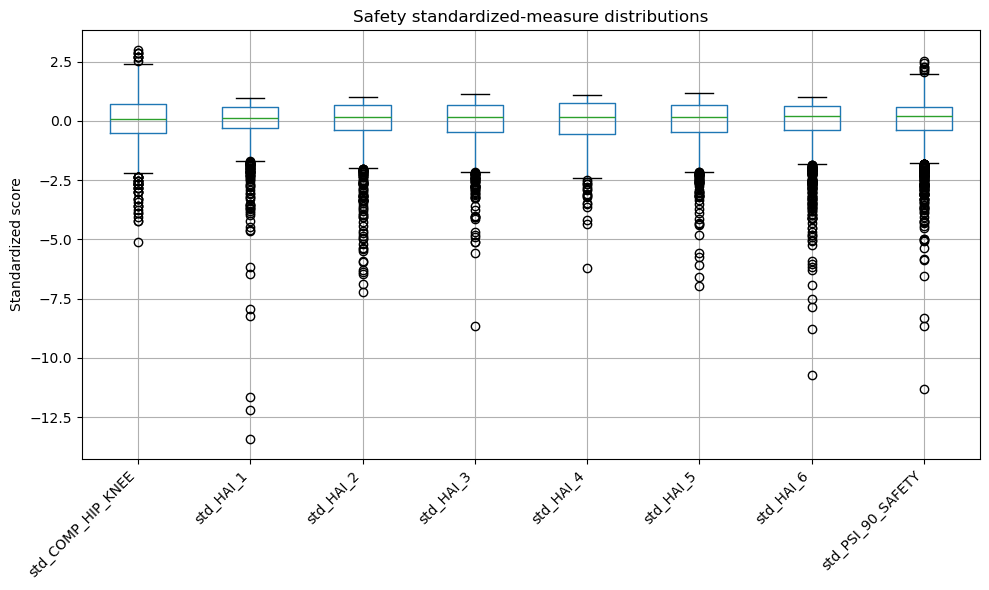

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
df[std_cols].boxplot(ax=ax)
ax.set_title("Safety standardized-measure distributions")
ax.set_ylabel("Standardized score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Check 11A — Standalone validation

### Why 11A exists

This is the **contingency / backup validation**.

It does not depend on Fiona's output or on any other Python-generated reference file. It uses only the current `OUTCOME_SAFETY.csv` and the documented relationships among its columns.

11A verifies:

1. reporting flags agree with actual data;
2. `total_cnt` agrees with reported measures;
3. `measure_wt` follows `1 / total_cnt`;
4. `score_before_std` equals the average of reported standardized measures;
5. `grp_score` follows its formula;
6. standardized measures have the expected standardized-scale behavior.

### What 11A can establish

It can establish that the Safety output is internally consistent.

### What 11A cannot establish

It cannot prove that every standardized value is exactly the same as the previous Program 0 output. That is the purpose of 11B.

In [13]:
check_11a = {
    "reporting_flags_match_data": flag_check["mismatches"].sum() == 0,
    "total_cnt_matches_reported_measures": not count_mismatch.any(),
    "measure_weight_formula": np.allclose(
        weighted_rows["measure_wt"], expected_weight, atol=1e-6, rtol=0
    ),
    "score_before_std_formula": np.allclose(
        calculated_score.loc[score_rows],
        df.loc[score_rows, "score_before_std"],
        atol=1e-6,
        rtol=0
    ),
    "grp_score_formula": (grp_diff <= 0.001).all(),
    "standardized_measure_sanity": mean_ok.all() and std_ok.all()
}

check_11a_table = pd.DataFrame.from_dict(check_11a, orient="index", columns=["PASS"])
display(check_11a_table)

assert check_11a_table["PASS"].all()

print("CHECK 11A: PASS")
print("OUTCOME_SAFETY.csv passes the standalone internal-consistency validation.")

,PASS
reporting_flags_match_data,True
total_cnt_matches_reported_measures,True
measure_weight_formula,True
score_before_std_formula,True
grp_score_formula,True
standardized_measure_sanity,True


CHECK 11A: PASS
OUTCOME_SAFETY.csv passes the standalone internal-consistency validation.


## 13. Check 11B — Optional previous-step cross-check

This is the direct upstream comparison.

The project documentation explicitly lists:

`std_data_2025jul_analysis.csv`

as a CSV output dataset containing standardized data. This notebook therefore uses that **documented filename**, rather than inventing a filename for Fiona's Python work.

If the file is not physically available yet:

- 11A still runs normally;
- 11B reports **PENDING**;
- the notebook does not treat missing reference data as a failure.

When the reference file is available, 11B compares the matching `std_...` columns by `PROVIDER_ID`, including both numerical values and missing-value patterns.

In [14]:
# This is the explicitly documented SAS output filename.
# Do not substitute an assumed Python filename here.
REFERENCE_FILE = DATA / "SAS Output CSV/STD_DATA_2025JUL_ANALYSIS.csv"

print("Reference file:", REFERENCE_FILE)

if not REFERENCE_FILE.exists():
    check_11b_status = "PENDING"
    print("\nCHECK 11B: PENDING")
    print("The documented previous-step reference file is not currently available.")
else:
    ref = pd.read_csv(REFERENCE_FILE)

    assert "PROVIDER_ID" in ref.columns
    reference_std_cols = [c for c in ref.columns if c.startswith("std_")]
    comparable = [c for c in std_cols if c in reference_std_cols]

    print("Safety std_ columns:", len(std_cols))
    print("Matching reference std_ columns:", len(comparable))

    assert set(comparable) == set(std_cols), (
        "Not all Safety standardized measures are present in the reference file."
    )
    assert ref["PROVIDER_ID"].duplicated().sum() == 0

    merged = df[["PROVIDER_ID"] + std_cols].merge(
        ref[["PROVIDER_ID"] + std_cols],
        on="PROVIDER_ID",
        how="outer",
        suffixes=("_safety", "_reference"),
        indicator=True
    )

    assert (merged["_merge"] == "both").all()

    rows = []
    for c in std_cols:
        a = merged[f"{c}_safety"]
        b = merged[f"{c}_reference"]

        rows.append({
            "measure": c,
            "max_abs_diff": (a - b).abs().max(),
            "missing_safety": int(a.isna().sum()),
            "missing_reference": int(b.isna().sum()),
            "missing_pattern_match": bool((a.isna() == b.isna()).all())
        })

    comparison = pd.DataFrame(rows)
    display(comparison)

    values_match = comparison["max_abs_diff"].le(1e-6).all()
    missing_match = comparison["missing_pattern_match"].all()

    if values_match and missing_match:
        check_11b_status = "PASS"
        print("CHECK 11B: PASS")
    else:
        check_11b_status = "FAIL"
        print("CHECK 11B: FAIL")

    assert values_match
    assert missing_match

Reference file: /Users/dianechege/Abt-Global-1B-ai-powered-sas-migration/data/Project_1/SAS Output CSV/STD_DATA_2025JUL_ANALYSIS.csv
Safety std_ columns: 8
Matching reference std_ columns: 8


,measure,max_abs_diff,missing_safety,missing_reference,missing_pattern_match
0,std_COMP_HIP_KNEE,0.0,2838,2838,True
1,std_HAI_1,0.0,2587,2587,True
2,std_HAI_2,0.0,2314,2314,True
3,std_HAI_3,0.0,2778,2778,True
4,std_HAI_4,0.0,3919,3919,True
5,std_HAI_5,0.0,2857,2857,True
6,std_HAI_6,0.0,1613,1613,True
7,std_PSI_90_SAFETY,0.0,1610,1610,True


CHECK 11B: PASS


## 14. Final validation summary

The status labels deliberately distinguish:

- **PASS** — the check actually ran and passed.
- **PENDING** — the check needs an external reference file that is not currently available.
- **FAIL** — the check ran and found a discrepancy.

This prevents a missing upstream file from being confused with a failed calculation.

In [15]:
summary = pd.DataFrame({
    "Check": [
        "3 — Reporting flags match data",
        "4 — total_cnt matches reported measures",
        "5 — measure_wt formula",
        "6 — score_before_std formula",
        "7 — grp_score formula",
        "8 — Standardized-measure sanity",
        "11A — Standalone validation",
        "11B — Previous-step cross-check"
    ],
    "Status": [
        "PASS" if check_11a["reporting_flags_match_data"] else "FAIL",
        "PASS" if check_11a["total_cnt_matches_reported_measures"] else "FAIL",
        "PASS" if check_11a["measure_weight_formula"] else "FAIL",
        "PASS" if check_11a["score_before_std_formula"] else "FAIL",
        "PASS" if check_11a["grp_score_formula"] else "FAIL",
        "PASS" if check_11a["standardized_measure_sanity"] else "FAIL",
        "PASS",
        check_11b_status
    ]
})

display(summary)

,Check,Status
0,3 — Reporting flags match data,PASS
1,4 — total_cnt matches reported measures,PASS
2,5 — measure_wt formula,PASS
3,6 — score_before_std formula,PASS
4,7 — grp_score formula,PASS
5,8 — Standardized-measure sanity,PASS
6,11A — Standalone validation,PASS
7,11B — Previous-step cross-check,PASS


## 15. Conclusions

### What the standalone work gives us

The notebook independently checks the internal chain:

**standardized measures → reporting flags → total count → measure weight → group score → standardized group score**

That gives us a meaningful validation even before the previous-step reference file is available.

### Why keep 11B?

11A and 11B answer different questions:

- **11A:** Does `OUTCOME_SAFETY.csv` make sense internally and follow the documented formulas?
- **11B:** Does the standardized input in `OUTCOME_SAFETY.csv` match the previous-step standardized output?

Keeping both makes the notebook more robust. If the upstream file is unavailable, the notebook still works. When it becomes available, the direct comparison provides an additional level of validation.

### Important limitation

Internal consistency is not the same thing as proving agreement with an upstream answer key. Therefore, 11B should remain in the notebook as a deferred cross-check rather than being removed.